fase 1 analise exploratoria

olhando as 3 primeiras linhas para entender a carinha da base:
   genero  idoso tem_parceiro tem_dependentes  meses_contrato  \
0  Female      0          Yes              No             1.0   
1    Male      0           No              No            34.0   
2    Male      0           No              No             2.0   

  servico_telefone  linhas_multiplas servico_internet seguranca_online  \
0               No  No phone service              DSL               No   
1              Yes                No              DSL              Yes   
2              Yes                No              DSL              Yes   

  backup_online protecao_dispositivo suporte_tecnico streaming_tv  \
0           Yes                   No              No           No   
1            No                  Yes              No           No   
2           Yes                   No              No           No   

  streaming_filmes   tipo_contrato fatura_digital  metodo_pagamento  \
0 

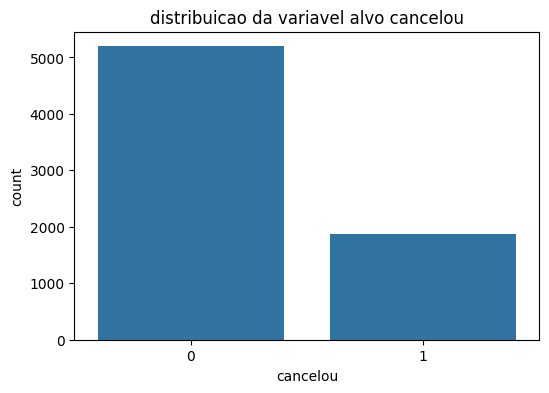

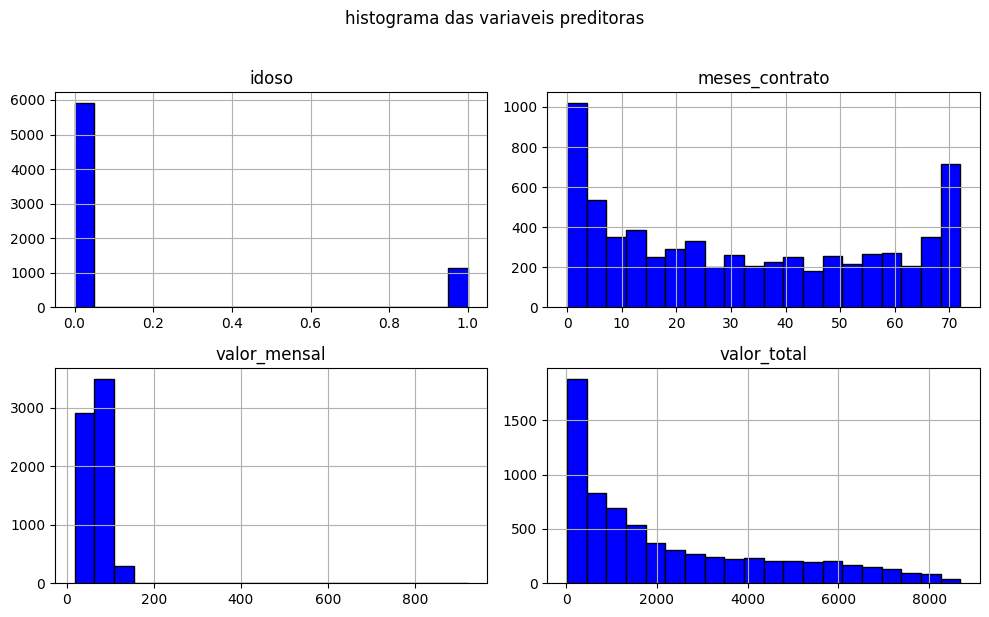

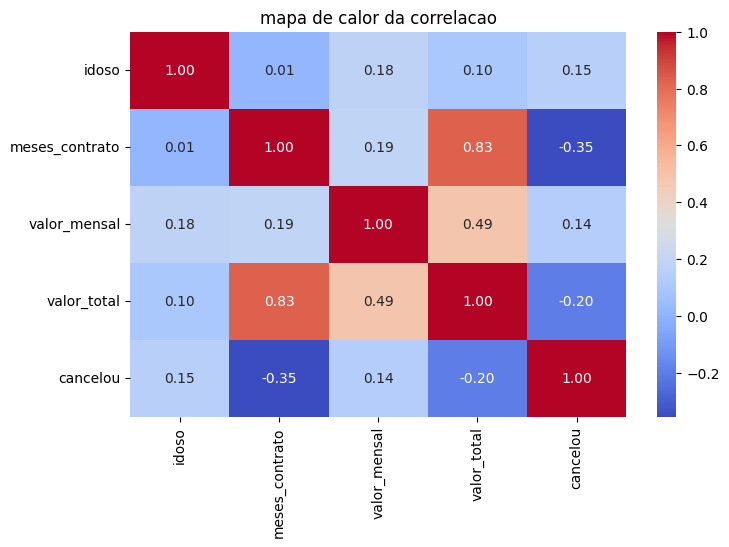


evidencia do mapa de calor: as variaveis meses_contrato e valor_total tem uma correlacao acima de 0.8.
conclusao: isso causa multicolinearidade. vou criar uma variavel nova na fase 3 para resumir essas duas e nao confundir o algoritmo.


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# fase 1 analise exploratoria eda
print("fase 1 analise exploratoria")
df = pd.read_csv('/content/DATA/dataset_recuperacao_telecom.csv')
if 'id_cliente' in df.columns:
    df = df.drop('id_cliente', axis=1)

print("\nolhando as 3 primeiras linhas para entender a carinha da base:")
print(df.head(3))

print("\nverificando a contagem da variavel alvo cancelou:")
print(df['cancelou'].value_counts())
print("evidencia: temos mais de 5000 clientes que nao cancelaram e apenas uns 1800 que cancelaram.")
print("conclusao: a base e muito desbalanceada. vou ter que fazer um undersampling na fase 4 senao o modelo vai chutar 0 pra todo mundo.")

plt.figure(figsize=(6, 4))
sns.countplot(x='cancelou', data=df)
plt.title('distribuicao da variavel alvo cancelou')
plt.show()

colunas_numericas = df.select_dtypes(include=['float64', 'int64']).columns.drop('cancelou', errors='ignore')
df[colunas_numericas].hist(bins=20, figsize=(10, 6), color='blue', edgecolor='black')
plt.suptitle('histograma das variaveis preditoras', y=1.02)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
colunas_para_correlacao = colunas_numericas.tolist()
if 'cancelou' in df.columns:
    colunas_para_correlacao.append('cancelou')
sns.heatmap(df[colunas_para_correlacao].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('mapa de calor da correlacao')
plt.show()

print("\nevidencia do mapa de calor: as variaveis meses_contrato e valor_total tem uma correlacao acima de 0.8.")
print("conclusao: isso causa multicolinearidade. vou criar uma variavel nova na fase 3 para resumir essas duas e nao confundir o algoritmo.")


fase 2 limpeza e tratamento de dados
linhas duplicadas encontradas na base: 0

analise de outliers via boxplot antes de tratar os nulos:


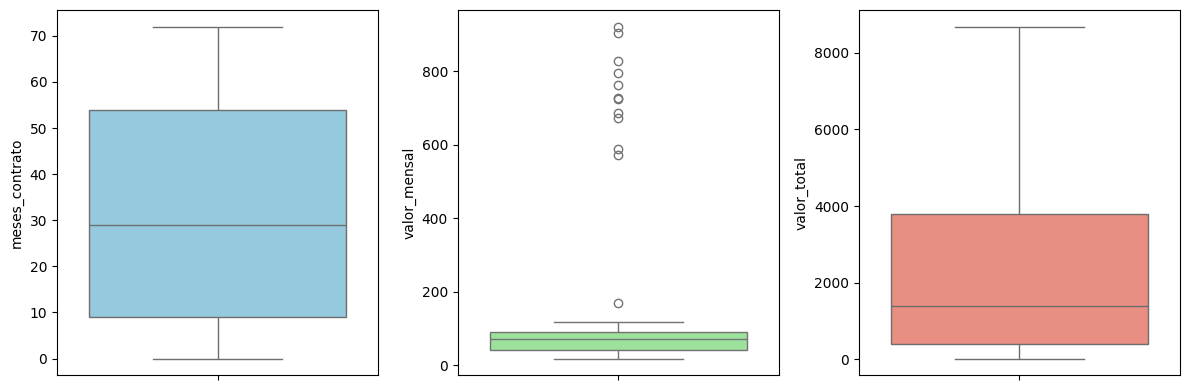


verificando valores nulos nas colunas financeiras e de contrato antes do tratamento:
meses_contrato    0
valor_mensal      0
valor_total       0
dtype: int64

conclusao: como os boxplots que acabamos de gerar mostraram valores muito dispersos e picos irregulares outliers decidi preencher os nulos com a mediana e nao com a media para nao distorcer a base de dados.

verificando valores nulos depois de preencher com a mediana:
meses_contrato    0
valor_mensal      0
valor_total       0
dtype: int64
conclusao: base limpa sem duplicadas e sem nulos pronta para a proxima fase.


In [22]:
# fase 2 limpeza e tratamento de dados data prep
print("\nfase 2 limpeza e tratamento de dados")

duplicadas = df.duplicated().sum()
print("linhas duplicadas encontradas na base:", duplicadas)
df.drop_duplicates(inplace=True)

print("\nanalise de outliers via boxplot antes de tratar os nulos:")
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sns.boxplot(y=df['meses_contrato'], color='skyblue')
plt.subplot(1, 3, 2)
sns.boxplot(y=df['valor_mensal'], color='lightgreen')
plt.subplot(1, 3, 3)
sns.boxplot(y=df['valor_total'], color='salmon')
plt.tight_layout()
plt.show()

print("\nverificando valores nulos nas colunas financeiras e de contrato antes do tratamento:")
print(df[['meses_contrato', 'valor_mensal', 'valor_total']].isnull().sum())

print("\nconclusao: como os boxplots que acabamos de gerar mostraram valores muito dispersos e picos irregulares outliers decidi preencher os nulos com a mediana e nao com a media para nao distorcer a base de dados.")

colunas_com_nulos = ['meses_contrato', 'valor_mensal', 'valor_total']
for col in colunas_com_nulos:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

print("\nverificando valores nulos depois de preencher com a mediana:")
print(df[['meses_contrato', 'valor_mensal', 'valor_total']].isnull().sum())
print("conclusao: base limpa sem duplicadas e sem nulos pronta para a proxima fase.")

In [16]:
# fase 3 feature engineering
print("\nfase 3 feature engineering")

df['gasto_medio_mensal'] = df['valor_total'] / df['meses_contrato']
df['gasto_medio_mensal'] = df['gasto_medio_mensal'].replace([np.inf, -np.inf], np.nan)
df['gasto_medio_mensal'] = df['gasto_medio_mensal'].fillna(0)

print("amostra das colunas para ver se o calculo da nova variavel gasto_medio_mensal deu certo:")
print(df[['meses_contrato', 'valor_total', 'gasto_medio_mensal']].head(5))
print("conclusao: calculo feito e tratei logo os valores infinitos de quem tinha 0 meses de contrato preenchendo com zero.")


fase 3 feature engineering
amostra das colunas para ver se o calculo da nova variavel gasto_medio_mensal deu certo:
   meses_contrato  valor_total  gasto_medio_mensal
0             1.0        29.85           29.850000
1            34.0      1889.50           55.573529
2             2.0       108.15           54.075000
3            45.0      1840.75           40.905556
4             2.0       151.65           75.825000
conclusao: calculo feito e tratei logo os valores infinitos de quem tinha 0 meses de contrato preenchendo com zero.


In [17]:
# fase 4 divisao e balanceamento dos dados
# primeiro usei o get_dummies com drop_first=True pra transformar as colunas de texto em numeros 0 e 1
# porque o algoritmo nao sabe ler texto
# depois separei os dados 80% pra treino e 20% pra teste
# usei o stratify=y pra garantir que o nivel de dificuldade continuasse igual pros dois lados
# justificativa do balanceamento como tinha muita gente que NAO cancelou fiz um undersampling pra igualar as duas classes
# mas detalhe super importante fiz isso SO nos dados de treino. o teste ficou intacto com os dados reais
# pra evitar o vazamento de dados data leakage e nao ter o perigo do modelo colar na prova final

# fase 4 divisao e balanceamento dos dados
print("\nfase 4 divisao e balanceamento")

colunas_categoricas = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=colunas_categoricas, drop_first=True, dtype=int)

X = df.drop('cancelou', axis=1)
y = df['cancelou']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

print("distribuicao do alvo no treino ANTES de balancear:")
print(y_train.value_counts())

treino_completo = pd.concat([X_train, y_train], axis=1)
classe_normal = treino_completo[treino_completo['cancelou'] == 0]
classe_cancelou = treino_completo[treino_completo['cancelou'] == 1]

classe_normal_subamostrada = resample(classe_normal, replace=False, n_samples=len(classe_cancelou), random_state=42)
treino_balanceado = pd.concat([classe_normal_subamostrada, classe_cancelou])

X_train_bal = treino_balanceado.drop('cancelou', axis=1)
y_train_bal = treino_balanceado['cancelou']

print("\ndistribuicao do alvo no treino DEPOIS do undersampling:")
print(y_train_bal.value_counts())
print("conclusao: agora o modelo vai treinar vendo a mesma quantidade de exemplos de quem cancelou e de quem nao cancelou. detalhe que nao mexi nos dados de teste para evitar vazamento de dados.")


fase 4 divisao e balanceamento
distribuicao do alvo no treino ANTES de balancear:
cancelou
0    4133
1    1487
Name: count, dtype: int64

distribuicao do alvo no treino DEPOIS do undersampling:
cancelou
0    1487
1    1487
Name: count, dtype: int64
conclusao: agora o modelo vai treinar vendo a mesma quantidade de exemplos de quem cancelou e de quem nao cancelou. detalhe que nao mexi nos dados de teste para evitar vazamento de dados.


In [18]:
# fase 5 escalonamento de variaveis
# justificativa do escalonamento o KNN e um modelo que mede a distancia entre os pontos
# se eu deixar o valor_total que chega na casa dos milhares misturado com os meses que vao so ate 72
# ele vai achar que o dinheiro importa mais so porque o numero e maior
# por isso usei o StandardScaler pra comprimir tudo na mesma escala mas apliquei ele APENAS no conjunto do KNN
# pra Arvore de Decisao nao precisa disso porque ela funciona so fazendo perguntas de corte
# a escala original dos numeros nao atrapalha em nada entao mantive os dados originais pra ela

# fase 5 escalonamento de variaveis
print("\nfase 5 escalonamento de variaveis")

colunas_continuas = ['meses_contrato', 'valor_mensal', 'valor_total', 'gasto_medio_mensal']
scaler = StandardScaler()

X_train_knn = X_train_bal.copy()
X_test_knn = X_test.copy()

X_train_knn[colunas_continuas] = scaler.fit_transform(X_train_bal[colunas_continuas])
X_test_knn[colunas_continuas] = scaler.transform(X_test[colunas_continuas])

print("amostra dos dados que vao pro KNN escalonados com StandardScaler:")
print(X_train_knn[['meses_contrato', 'valor_total']].head(3))

print("\namostra dos dados que vao pra arvore de decisao mantendo a escala original:")
print(X_train_bal[['meses_contrato', 'valor_total']].head(3))
print("conclusao: o knn precisa dos dados na mesma proporcao entre zero e um pra nao achar que a coluna valor importa mais que meses so porque o numero e maior. a arvore nao precisa disso porque usa regras de corte sim ou nao.")


fase 5 escalonamento de variaveis
amostra dos dados que vao pro KNN escalonados com StandardScaler:
      meses_contrato  valor_total
5732       -0.389940    -0.202044
1399       -0.600761    -0.809405
525         1.001476     1.200566

amostra dos dados que vao pra arvore de decisao mantendo a escala original:
      meses_contrato  valor_total
5732            19.0       1637.3
1399            14.0        294.5
525             52.0       4738.3
conclusao: o knn precisa dos dados na mesma proporcao entre zero e um pra nao achar que a coluna valor importa mais que meses so porque o numero e maior. a arvore nao precisa disso porque usa regras de corte sim ou nao.


In [20]:
# fase 6 ajuste de parametros e combate ao overfitting
# fiz uns testes mudando os botoes dos modelos pra ver onde eles comecavam a so decorar a base de dados overfitting
# no knn com K=3 poucos vizinhos ele tava decorando o treino. quando subi pra K=7 ele ficou mais estavel e generalizou bem no teste
# na arvore de decisao o overfitting foi gigante. quando deixei a arvore crescer sem limite max_depth=None
# o modelo quase gabaritou o treino 99% de acerto mas foi muito mal no teste porque decorou o nome de cada cliente
# entao cortei a profundidade dela pra 5. assim ela aprendeu so as regras gerais e a nota no teste subiu de verdade

print("\nfase 6 ajuste de parametros e combate ao overfitting")
print("vamos olhar as evidencias numericas pra ver onde o modelo esta decorando a base overfitting")

print("\ntestes do knn")
for k in [3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_knn, y_train_bal)
    acc_train = accuracy_score(y_train_bal, knn.predict(X_train_knn))
    acc_test = accuracy_score(y_test, knn.predict(X_test_knn))
    print("k:", k, "acuracia no treino:", round(acc_train, 4), "acuracia no teste:", round(acc_test, 4))

print("conclusao do knn: com k=3 a diferenca entre treino e teste mostra overfitting. k=7 ficou mais estavel.")

print("\ntestes da arvore de decisao")
for d in [3, 5, None]:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_bal, y_train_bal)
    acc_train = accuracy_score(y_train_bal, dt.predict(X_train_bal))
    acc_test = accuracy_score(y_test, dt.predict(X_test))
    d_label = "sem limite" if d is None else str(d)
    print("profundidade:", d_label, "acuracia no treino:", round(acc_train, 4), "acuracia no teste:", round(acc_test, 4))

print("conclusao da arvore: quando deixamos sem limite ela quase chega a 100 por cento no treino mas vai mal no teste. pura decoreba. limitando a profundidade para 5 ela generaliza super bem.")


fase 6 ajuste de parametros e combate ao overfitting
vamos olhar as evidencias numericas pra ver onde o modelo esta decorando a base overfitting

testes do knn
k: 3 acuracia no treino: 0.8423 acuracia no teste: 0.7132
k: 5 acuracia no treino: 0.8104 acuracia no teste: 0.7196
k: 7 acuracia no treino: 0.7989 acuracia no teste: 0.7302
conclusao do knn: com k=3 a diferenca entre treino e teste mostra overfitting. k=7 ficou mais estavel.

testes da arvore de decisao
profundidade: 3 acuracia no treino: 0.7256 acuracia no teste: 0.6705
profundidade: 5 acuracia no treino: 0.7626 acuracia no teste: 0.7374
profundidade: sem limite acuracia no treino: 0.9987 acuracia no teste: 0.6797
conclusao da arvore: quando deixamos sem limite ela quase chega a 100 por cento no treino mas vai mal no teste. pura decoreba. limitando a profundidade para 5 ela generaliza super bem.


In [21]:
# fase 7 avaliacao da acuracia e veredito final
# coloquei as melhores versoes dos dois modelos knn com k=7 e arvore com profundidade 5
# pra fazer o teste final usando os 20% da base que eles nunca tinham visto
# veredito final a arvore de decisao ganhou a disputa
# vou recomendar ela pra equipe de marketing da empresa
# o motivo nao e so porque ela acertou um pouquinho a mais mas sim porque a arvore e explicavel
# nao e uma caixa preta. da pra mostrar pro pessoal do negocio exatamente quais regrinhas
# estao definindo se o cliente vai cancelar ou nao
# o que facilita muito pra criar campanhas pra reter esses clientes

print("\nfase 7 veredito final")
print("agora vamos rodar os modelos campeoes apenas nos dados de teste intocados e extrair as metricas finais")

melhor_knn = KNeighborsClassifier(n_neighbors=7)
melhor_knn.fit(X_train_knn, y_train_bal)
acc_final_knn = accuracy_score(y_test, melhor_knn.predict(X_test_knn))

melhor_arvore = DecisionTreeClassifier(max_depth=5, random_state=42)
melhor_arvore.fit(X_train_bal, y_train_bal)
acc_final_arvore = accuracy_score(y_test, melhor_arvore.predict(X_test))

print("\nplacar final no teste real:")
print("acuracia do knn:", round(acc_final_knn * 100, 2), "por cento")
print("acuracia da arvore:", round(acc_final_arvore * 100, 2), "por cento")

print("\nveredito: a arvore de decisao ganhou.")
print("eu vou recomendar a arvore para a equipe de marketing porque alem de ela acertar um pouquinho a mais ela nao e uma caixa preta. o fato de as regras serem explicaveis ajuda o negocio a entender de verdade o que faz o cliente cancelar.")


fase 7 veredito final
agora vamos rodar os modelos campeoes apenas nos dados de teste intocados e extrair as metricas finais

placar final no teste real:
acuracia do knn: 73.02 por cento
acuracia da arvore: 73.74 por cento

veredito: a arvore de decisao ganhou.
eu vou recomendar a arvore para a equipe de marketing porque alem de ela acertar um pouquinho a mais ela nao e uma caixa preta. o fato de as regras serem explicaveis ajuda o negocio a entender de verdade o que faz o cliente cancelar.
